In [81]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [82]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backaward():
            self.grad += 1.0 * out.grad # should be += since there might be multiple paths to this node
            other.grad += 1.0 * out.grad
        out._backward = _backaward
        return out
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward  # fixed: was out.backward
        return out
    
    def __sub__(self, other): # self - other
        return self + (-other)
    def __neg__(self): # -self
        return self * -1
    
    def tanh(self):
        x = self.data
        t = math.tanh(x)  # numerically stable; avoids overflow from exp(2*x)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [83]:
a = Value(3.0, label='a')
a + 1

Value(data=4.0)

In [84]:
# a / b 
# a * (1 / b)
# a * (b ** -1)

In [85]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

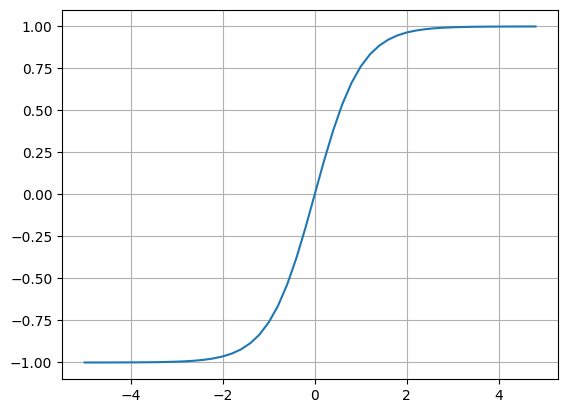

In [86]:
plt.plot(np.arange(-5.0, 5.0, 0.2), np.tanh(np.arange(-5.0, 5.0, 0.2))); plt.grid();

In [87]:
# inputs x1, x2
x1 = Value(2.0, label='x1') 
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


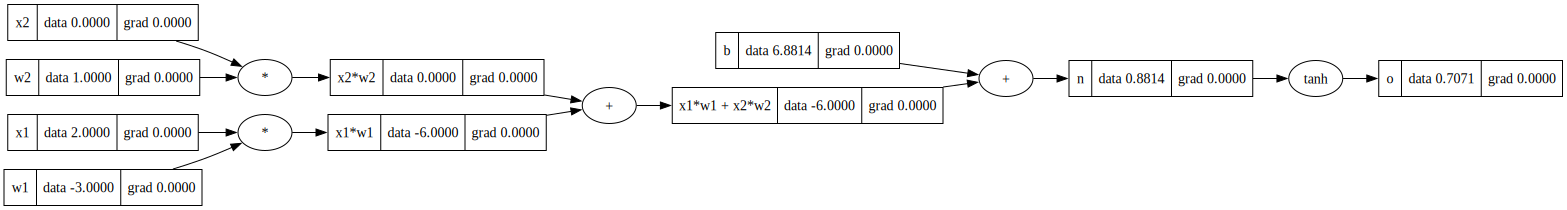

In [88]:
draw_dot(o)

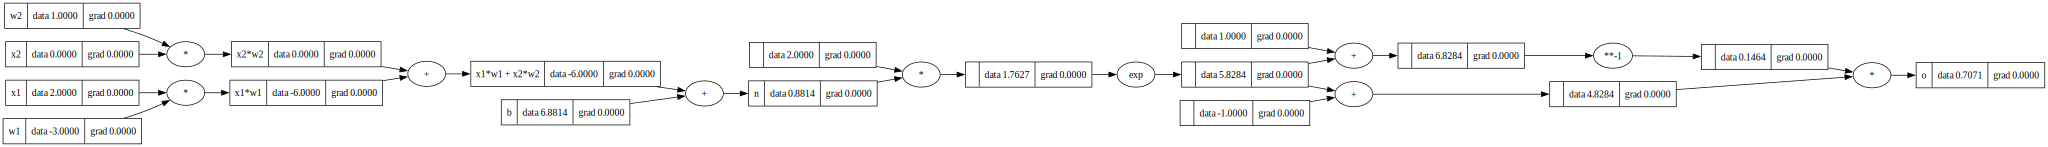

In [89]:
# inputs x1, x2
x1 = Value(2.0, label='x1') 
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh()
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
draw_dot(o)
# expect to see: 1. same as before 2. longer graph

In [90]:
o.backward()
# o.grad = 1.0
# topo = []
# visited = set()
# def build_topo(v):
#     if v not in visited:
#         visited.add(v)
#         for child in v._prev:
#             build_topo(child)
#         topo.append(v)
# build_topo(o)

# for node in reversed(topo):
#     node._backward()

In [91]:
import torch

x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True # enable gradient calculation for leaf nodes
x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()
b.requires_grad = True
n = x1 * w1 + x2 * w2 + b
o = n.tanh()

print(o.data.item())
o.backward()


print('-'*100)
print(x1.grad.item(), x2.grad.item(), w1.grad.item(), w2.grad.item(), b.grad.item()) # .item() to get the value of the tensor



0.7071066904050358
----------------------------------------------------------------------------------------------------
-1.5000003851533106 0.5000001283844369 1.0000002567688737 0.0 0.5000001283844369


In [92]:
torch.Tensor([2.0]).double().dtype # cast to double flaoting

torch.float64

In [93]:
torch.Tensor([[1, 2, 3], [4, 5, 6]]).shape


torch.Size([2, 3])

In [94]:
import random

class Neuron:
    def __init__(self, nin):
        # nin = number of inputs
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self, x):
        # w * x + b
        return 0.0

# explaination of __call__
x = [2.0, 3.0]
n = Neuron(2)
n(x) # when use this notation: n of x, it will call the __call__ method


0.0

In [95]:
import random

class Neuron:
    def __init__(self, nin):
        # nin = number of inputs
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # x is a list of values
        # compute the linear combination
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        # apply the activation function
        return act.tanh()
    
    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        # nout = number of neurons in the layer
        # nin = number of inputs to each neuron
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons] # apply each neuron to the input
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        # nouts is a list of number of neurons in each layer
        # nin is the number of inputs to the first layer
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        
    
    

In [96]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.7288881466323308)

In [97]:
n.parameters()

[Value(data=0.08318327567768469),
 Value(data=-0.3119613799857843),
 Value(data=-0.10605490310041077),
 Value(data=-0.3064548417568076),
 Value(data=-0.5281566032112202),
 Value(data=0.2928021410794541),
 Value(data=0.09370507654806093),
 Value(data=-0.00837761916186408),
 Value(data=-0.055398996006708945),
 Value(data=-0.5049337952402788),
 Value(data=0.5617652318305624),
 Value(data=0.6314455038260087),
 Value(data=0.8777366869223961),
 Value(data=0.02741612289934592),
 Value(data=0.9615922899738025),
 Value(data=-0.6961799928322936),
 Value(data=0.3902382693586355),
 Value(data=-0.7385114657667773),
 Value(data=0.36943038381758475),
 Value(data=-0.6085967253183076),
 Value(data=-0.2971799095958674),
 Value(data=0.35356241454718584),
 Value(data=-0.5451976211132064),
 Value(data=0.27844581692673565),
 Value(data=0.007700182652612408),
 Value(data=0.8819090263217493),
 Value(data=0.2060235577590548),
 Value(data=-0.94279467549126),
 Value(data=0.33083180356982034),
 Value(data=0.35774

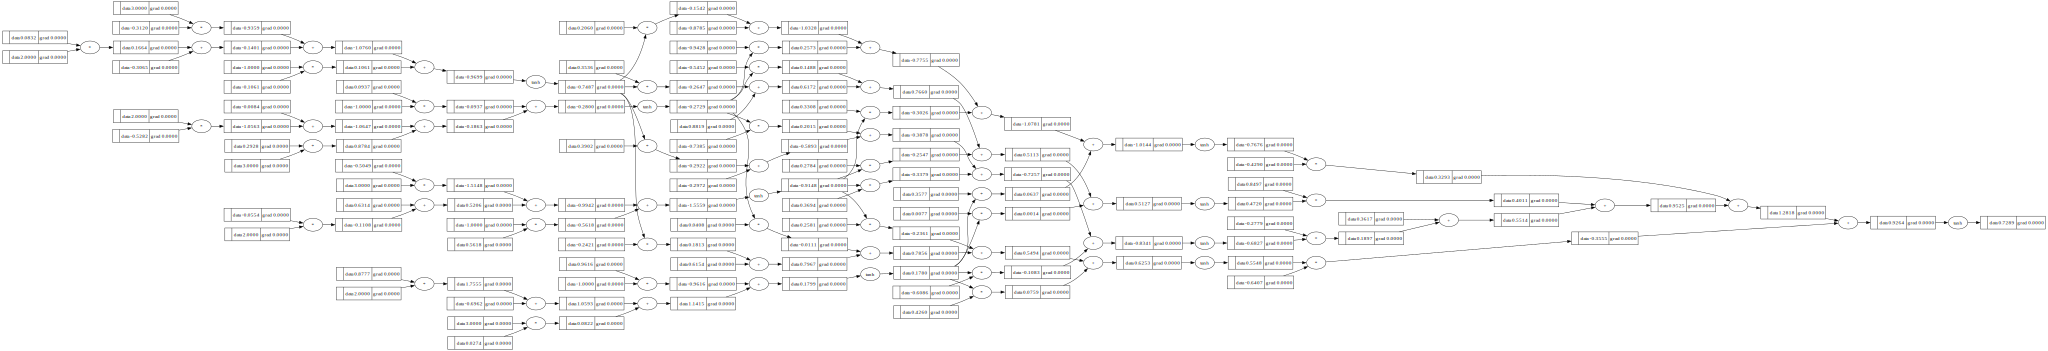

In [98]:
draw_dot(n(x))

In [108]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired outputs



In [100]:
# ypred = [n(x) for x in xs]
# ypred
# compute loss (mean squared error)
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss.backward()
print(loss.data)

# print(n.layers[0].neurons[0].w[1].grad)  # should now be non-zero


4.0


In [101]:
n.layers[0].neurons[0].w[1].data

-0.3119613799857843

In [102]:
for p in n.parameters():
    p.data += -0.001 * p.grad

ypred = [n(x) for x in xs]
ypred



[Value(data=0.7288881466323308),
 Value(data=0.3090821607467237),
 Value(data=0.6767327269622788),
 Value(data=0.784351117248105)]

In [109]:
for k in range(1000):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    # zero gradients before backward pass
    for p in n.parameters():
        p.grad = 0.0
    
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    for p in n.parameters():
        p.data += -0.05 * p.grad
        print(f"k={k}, loss={loss.data}")
    # if k % 10 == 0:
    #     print(f"k={k}, loss={loss.data}")
    # if loss.data < 0.01:
    #     print(f"k={k}, loss={loss.data}")
    #     break

ypred = [n(x) for x in xs]
ypred


k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, loss=0.0002662301914595279
k=0, los

[Value(data=0.9943836141134013),
 Value(data=-0.9945682738432451),
 Value(data=-0.9917039261174201),
 Value(data=0.993179580280933)]

# most common neural net mistakes
1. you didn't try to overfit a single batch first
2. you forgot to toggle train/eval mode for the net
3. you forgot to .zero_grad() (in pytorch) before .backward()
4. you passed sofmatxed outputs to a loss that expects raw logits. 